<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 50px 40px; border-radius: 15px; text-align: center; margin-bottom: 10px;">
  <h1 style="color: #e94560; font-size: 42px; font-weight: 900; letter-spacing: 2px; margin: 0;">🌸 IRIS FLOWER CLASSIFICATION</h1>
  <p style="color: #a8d8ea; font-size: 18px; margin: 15px 0 5px;">End-to-End Machine Learning Project</p>
  <hr style="border-color: #e94560; width: 60%; margin: 20px auto;">
  <table style="margin: 0 auto; color: white; font-size: 15px;">
    <tr><td style="padding: 5px 30px;">👤 <b>Author</b></td><td>Sonu Kumar</td></tr>
    <tr><td style="padding: 5px 30px;">🏢 <b>Internship</b></td><td>AICTE Oasis Infobyte</td></tr>
    <tr><td style="padding: 5px 30px;">📅 <b>Batch</b></td><td>March – April 2026</td></tr>
    <tr><td style="padding: 5px 30px;">📌 <b>Task</b></td><td>Task 1 — ML Classification</td></tr>
  </table>
</div>


<div style="background:#f0f4ff; border-left: 6px solid #3498db; border-radius:8px; padding: 20px 25px; margin: 10px 0;">
<h2 style="color:#2c3e50; margin-top:0;">📖 Project Overview</h2>
<p style="font-size:15px; color:#34495e; line-height:1.8;">
The <b>Iris Dataset</b> is one of the most famous datasets in machine learning. It contains measurements of <b>150 iris flowers</b> from three different species.
The goal of this project is to build a classification model that can <b>predict the species</b> of an iris flower based on its physical measurements.
</p>
<h3 style="color:#2c3e50;">🎯 Objective</h3>
<ul style="font-size:15px; color:#34495e; line-height:2;">
  <li>Perform thorough <b>Exploratory Data Analysis (EDA)</b></li>
  <li>Preprocess and prepare data for ML models</li>
  <li>Train and compare <b>5 different ML algorithms</b></li>
  <li>Select the <b>best performing model</b> using cross-validation</li>
  <li>Visualize results with professional dashboards</li>
</ul>
<h3 style="color:#2c3e50;">🌸 Target Classes</h3>
<table style="border-collapse:collapse; font-size:14px;">
  <tr style="background:#3498db; color:white;"><th style="padding:8px 20px;">Species</th><th style="padding:8px 20px;">Samples</th><th style="padding:8px 20px;">Key Feature</th></tr>
  <tr style="background:#eaf4fb;"><td style="padding:8px 20px;">🌿 Iris Setosa</td><td>50</td><td>Smallest petals</td></tr>
  <tr><td style="padding:8px 20px;">🌺 Iris Versicolor</td><td>50</td><td>Medium sized</td></tr>
  <tr style="background:#eaf4fb;"><td style="padding:8px 20px;">🌸 Iris Virginica</td><td>50</td><td>Largest petals</td></tr>
</table>
</div>


---
## 📦 Step 1 — Import Libraries
> All required Python libraries are imported here. Each library serves a specific purpose in our ML pipeline.

In [1]:
# ── Data Manipulation ─────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualization ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns

# ── Machine Learning ──────────────────────────────────────────
from sklearn.model_selection   import train_test_split, cross_val_score
from sklearn.preprocessing     import LabelEncoder, StandardScaler
from sklearn.linear_model      import LogisticRegression
from sklearn.tree              import DecisionTreeClassifier
from sklearn.ensemble          import RandomForestClassifier
from sklearn.svm               import SVC
from sklearn.neighbors         import KNeighborsClassifier
from sklearn.metrics           import (accuracy_score, classification_report,
                                        confusion_matrix, ConfusionMatrixDisplay)

import warnings
warnings.filterwarnings('ignore')

# ── Style Settings ────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

COLORS  = ['#2ecc71', '#3498db', '#e74c3c']
SPECIES = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
FEATURES= ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

print('✅ All libraries imported successfully!')
print(f'   pandas     : {pd.__version__}')
print(f'   numpy      : {np.__version__}')
print(f'   seaborn    : {sns.__version__}')

✅ All libraries imported successfully!
   pandas     : 2.2.2
   numpy      : 1.26.4
   seaborn    : 0.13.2


---
## 📂 Step 2 — Load Dataset
> Loading the Iris dataset from the provided Excel file. We also check its basic structure immediately after loading.

In [2]:
# ── Load from Excel ───────────────────────────────────────────
df = pd.read_excel('Iris.xlsx')

# Drop Id column — not useful for ML
if 'Id' in df.columns:
    df.drop(columns=['Id'], inplace=True)

print(f'✅ Dataset loaded successfully!')
print(f'   Shape   : {df.shape[0]} rows × {df.shape[1]} columns')
print(f'   Features: {list(df.columns[:-1])}')
print(f'   Target  : {df.columns[-1]}')

✅ Dataset loaded successfully!
   Shape   : 150 rows × 5 columns
   Features: ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
   Target  : Species


In [3]:
# ── Preview first 10 rows ─────────────────────────────────────
print('📌 First 10 rows of the dataset:')
df.head(10)

📌 First 10 rows of the dataset:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa
9,4.9,3.1,1.5,0.1,Iris-setosa


In [4]:
# ── Last 5 rows ───────────────────────────────────────────────
print('📌 Last 5 rows of the dataset:')
df.tail(5)

📌 Last 5 rows of the dataset:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


---
## 🔍 Step 3 — Data Exploration & Understanding
> Before modelling, it is essential to deeply understand what the data looks like — its types, distribution, and quality.

In [5]:
# ── Data Types & Memory ───────────────────────────────────────
print('📌 Dataset Info:')
df.info()

📌 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [6]:
# ── Statistical Summary ───────────────────────────────────────
print('📌 Statistical Summary (all 4 features):')
df.describe().round(3)

📌 Statistical Summary (all 4 features):


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000,150.000,150.000,150.000
mean,5.843,3.054,3.759,1.199
std,0.828,0.434,1.764,0.763
min,4.300,2.000,1.000,0.100
25%,5.100,2.800,1.600,0.300
50%,5.800,3.000,4.350,1.300
75%,6.400,3.300,5.100,1.800
max,7.900,4.400,6.900,2.500


In [7]:
# ── Missing Values Check ──────────────────────────────────────
missing = df.isnull().sum()
print('📌 Missing Values per Column:')
print(missing)
print(f'\n✅ Total missing values: {missing.sum()} — Dataset is CLEAN!')

📌 Missing Values per Column:
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

✅ Total missing values: 0 — Dataset is CLEAN!


In [8]:
# ── Class Distribution ────────────────────────────────────────
print('📌 Class Distribution (Target Variable):')
dist = df['Species'].value_counts()
print(dist)
print(f'\n✅ Dataset is perfectly BALANCED — {dist.iloc[0]} samples each')

📌 Class Distribution (Target Variable):
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

✅ Dataset is perfectly BALANCED — 50 samples each


In [9]:
# ── Per-Species Statistics ────────────────────────────────────
print('📌 Per-Species Mean Values:')
df.groupby('Species').mean().round(3)

📌 Per-Species Mean Values:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
Species,,,,
Iris-setosa,5.006,3.418,1.464,0.244
Iris-versicolor,5.936,2.770,4.260,1.326
Iris-virginica,6.588,2.974,5.552,2.026


<div style="background:#fff9e6; border-left:6px solid #f39c12; border-radius:8px; padding:15px 20px; margin:10px 0;">
<b>💡 Key Observations from EDA:</b>
<ul style="line-height:2;">
  <li><b>No missing values</b> — dataset is clean and ready for modelling</li>
  <li><b>Perfectly balanced</b> — 50 samples per class, no class imbalance issue</li>
  <li><b>Setosa</b> has the smallest petal dimensions — easy to separate</li>
  <li><b>Versicolor vs Virginica</b> overlap slightly — harder to classify</li>
  <li>All features are <b>continuous numerical</b> values</li>
</ul>
</div>

---
## 📊 Step 4 — Exploratory Data Analysis (EDA) — Visualizations
> Visual exploration is the most powerful tool to understand patterns, distributions, and relationships in data.

### 4.1 — Feature Distributions (Histogram)

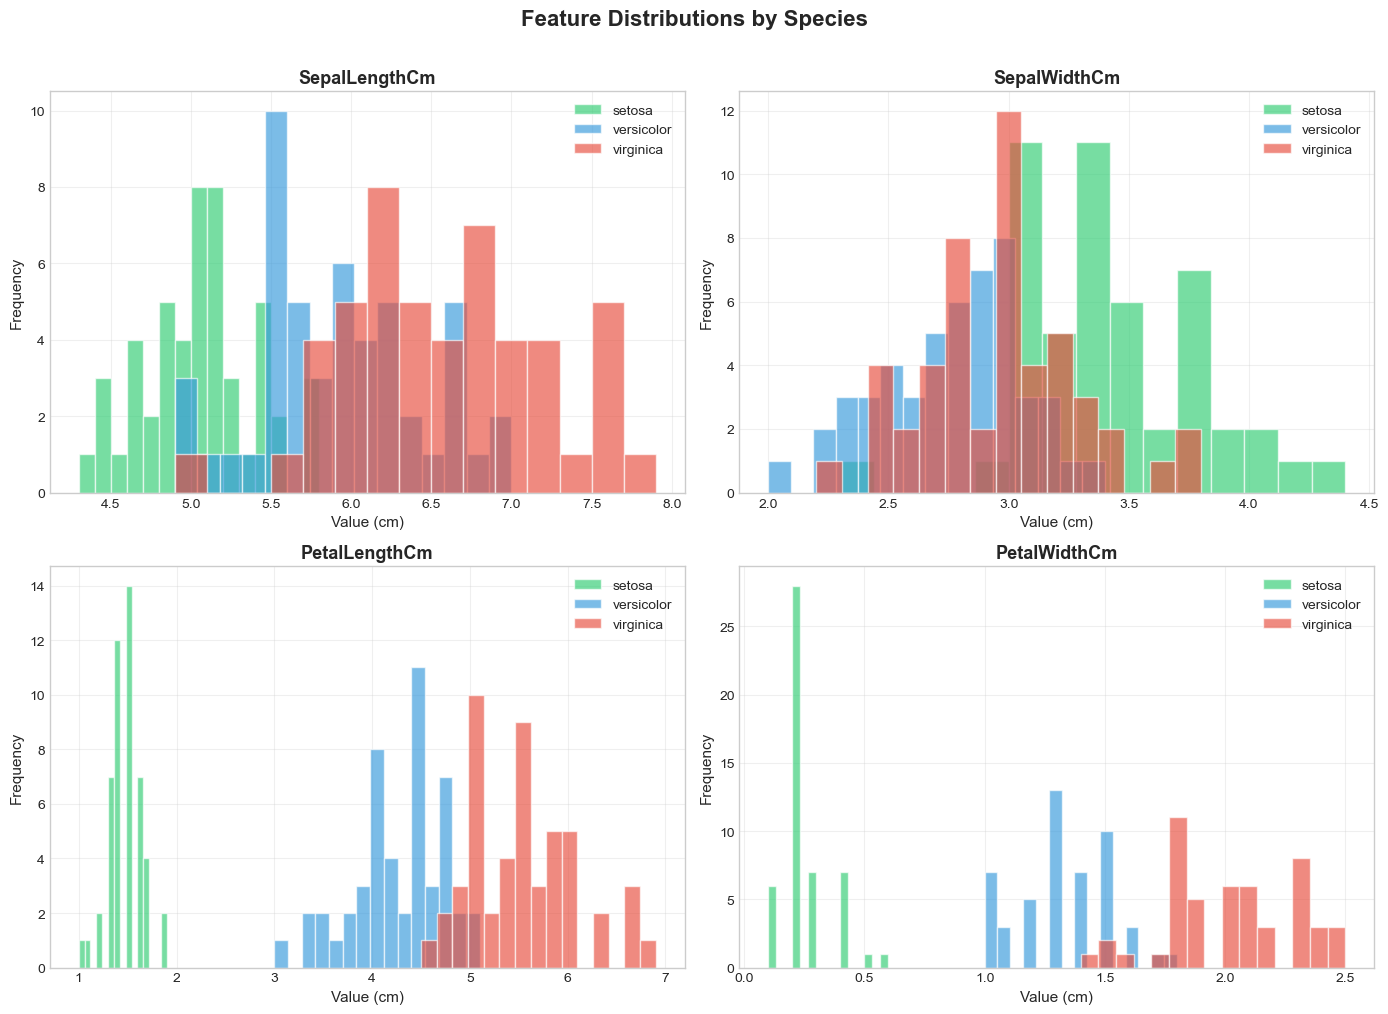

📌 Histogram saved → plot1_histograms.png


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Feature Distributions by Species', fontsize=16, fontweight='bold', y=1.01)

for ax, feat in zip(axes.flatten(), FEATURES):
    for j, sp in enumerate(SPECIES):
        ax.hist(df[df['Species'] == sp][feat], bins=15,
                alpha=0.65, color=COLORS[j],
                label=sp.replace('Iris-', ''), edgecolor='white')
    ax.set_title(feat, fontsize=13, fontweight='bold')
    ax.set_xlabel('Value (cm)', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plot1_histograms.png', dpi=150, bbox_inches='tight')
plt.show()
print('📌 Histogram saved → plot1_histograms.png')

### 4.2 — Boxplot Analysis

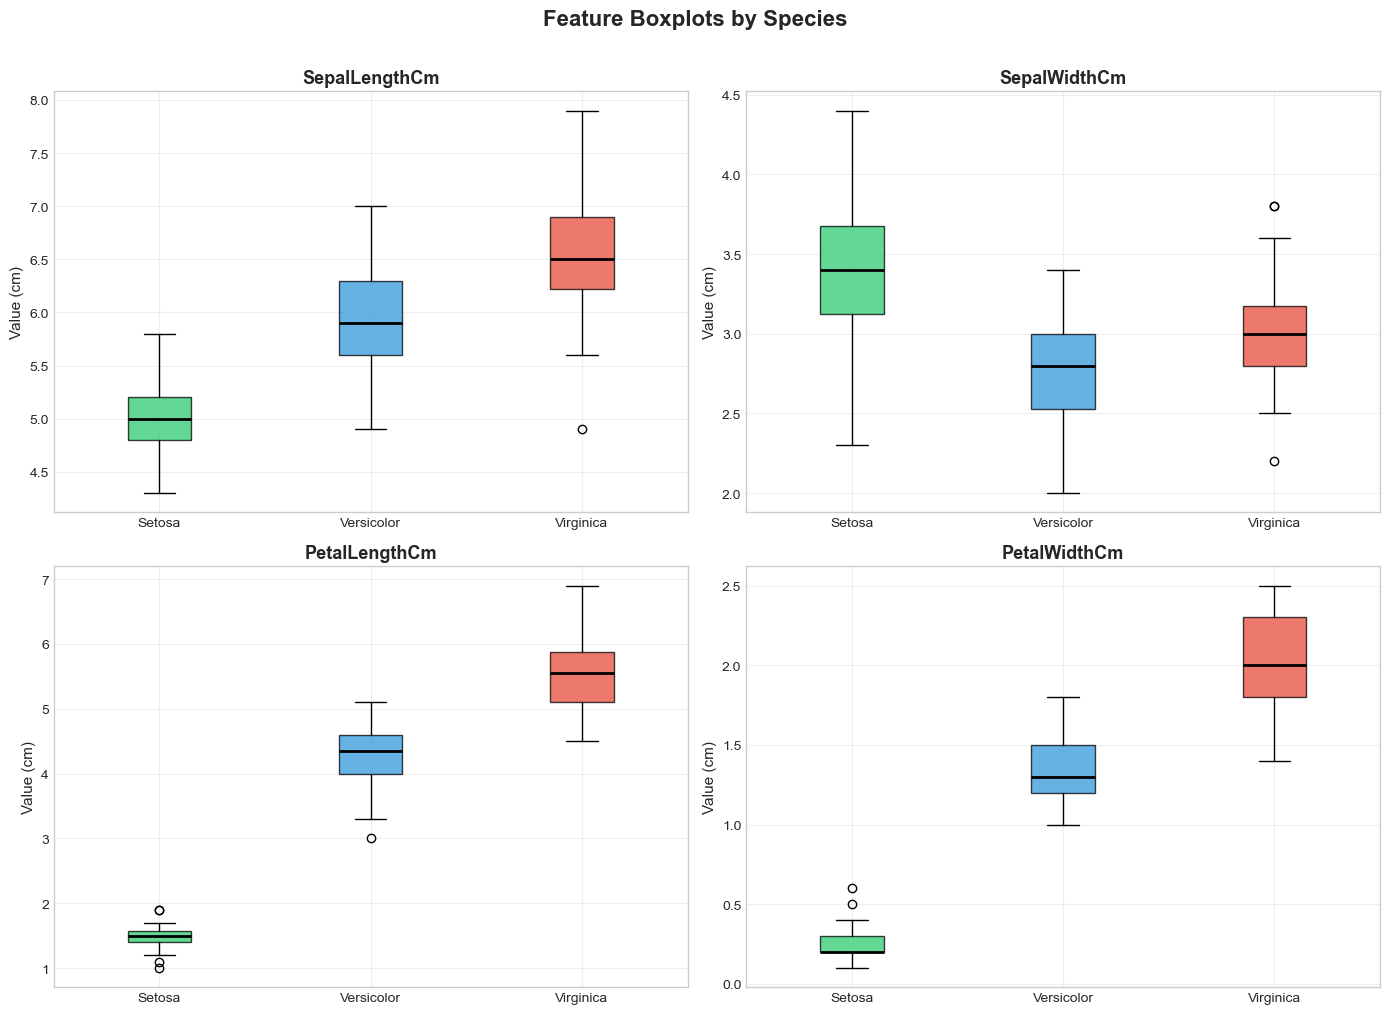

📌 Boxplot saved → plot2_boxplots.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Feature Boxplots by Species', fontsize=16, fontweight='bold', y=1.01)

for ax, feat in zip(axes.flatten(), FEATURES):
    data = [df[df['Species'] == sp][feat].values for sp in SPECIES]
    bp   = ax.boxplot(data, patch_artist=True,
                      labels=['Setosa', 'Versicolor', 'Virginica'],
                      medianprops=dict(color='black', linewidth=2))
    for patch, c in zip(bp['boxes'], COLORS):
        patch.set_facecolor(c); patch.set_alpha(0.75)
    ax.set_title(feat, fontsize=13, fontweight='bold')
    ax.set_ylabel('Value (cm)', fontsize=11)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plot2_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('📌 Boxplot saved → plot2_boxplots.png')

### 4.3 — Scatter Plot Analysis

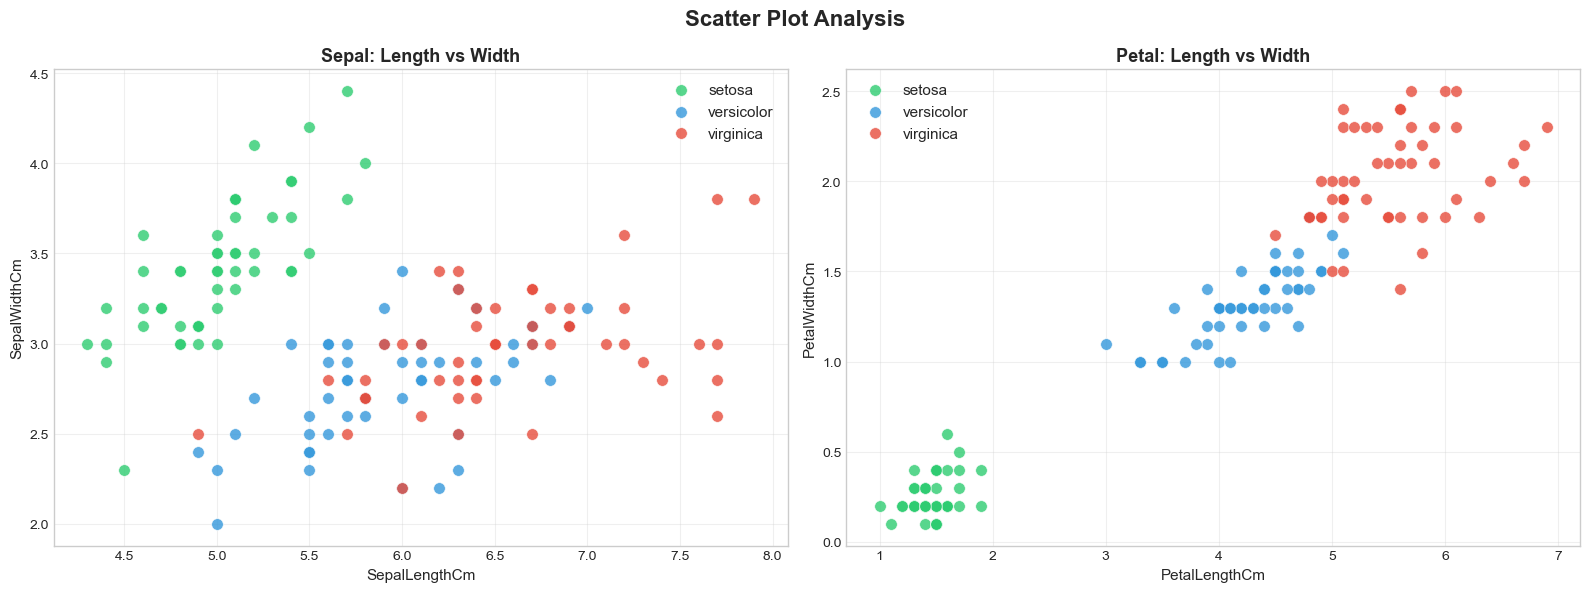

📌 Scatter plot saved → plot3_scatter.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Scatter Plot Analysis', fontsize=16, fontweight='bold')

pairs = [('SepalLengthCm', 'SepalWidthCm', 'Sepal'),
         ('PetalLengthCm', 'PetalWidthCm', 'Petal')]

for ax, (xf, yf, title) in zip(axes, pairs):
    for j, sp in enumerate(SPECIES):
        sub = df[df['Species'] == sp]
        ax.scatter(sub[xf], sub[yf], c=COLORS[j],
                   label=sp.replace('Iris-', ''),
                   s=70, alpha=0.8, edgecolors='white', linewidth=0.5)
    ax.set_title(f'{title}: Length vs Width', fontsize=13, fontweight='bold')
    ax.set_xlabel(xf, fontsize=11)
    ax.set_ylabel(yf, fontsize=11)
    ax.legend(fontsize=11, framealpha=0.9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plot3_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('📌 Scatter plot saved → plot3_scatter.png')

### 4.4 — Correlation Heatmap

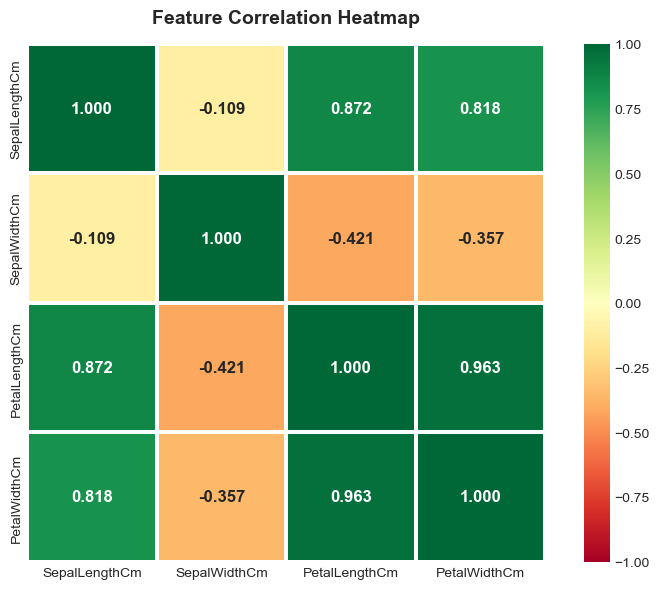

📌 Heatmap saved → plot4_heatmap.png

💡 High correlation (0.96) between PetalLength & PetalWidth
💡 SepalWidth has LOW correlation with other features — unique signal!


In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[FEATURES].corr()

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn',
            ax=ax, linewidths=1.5, square=True,
            annot_kws={'size': 12, 'weight': 'bold'},
            vmin=-1, vmax=1)

ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plot4_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('📌 Heatmap saved → plot4_heatmap.png')
print()
print('💡 High correlation (0.96) between PetalLength & PetalWidth')
print('💡 SepalWidth has LOW correlation with other features — unique signal!')

### 4.5 — Violin Plot & Pair Plot

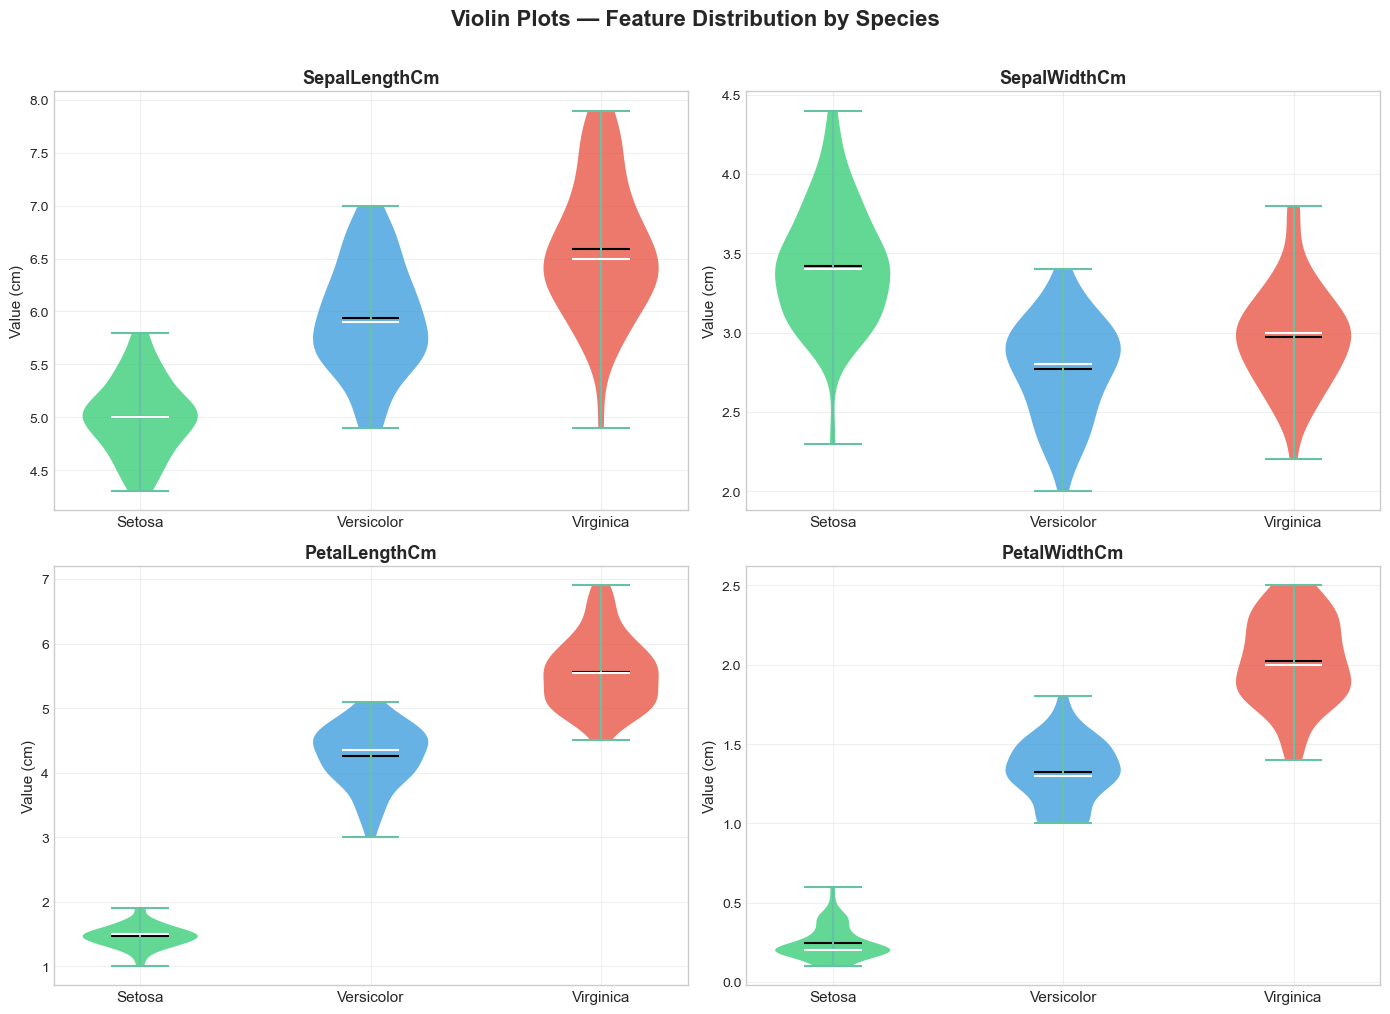

📌 Violin plot saved → plot5_violin.png


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Violin Plots — Feature Distribution by Species',
             fontsize=16, fontweight='bold', y=1.01)

for ax, feat in zip(axes.flatten(), FEATURES):
    vp = ax.violinplot(
        [df[df['Species'] == sp][feat].values for sp in SPECIES],
        showmeans=True, showmedians=True)
    for body, c in zip(vp['bodies'], COLORS):
        body.set_facecolor(c); body.set_alpha(0.75)
    vp['cmeans'].set_color('black')
    vp['cmedians'].set_color('white')
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(['Setosa', 'Versicolor', 'Virginica'], fontsize=11)
    ax.set_title(feat, fontsize=13, fontweight='bold')
    ax.set_ylabel('Value (cm)', fontsize=11)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plot5_violin.png', dpi=150, bbox_inches='tight')
plt.show()
print('📌 Violin plot saved → plot5_violin.png')

⏳ Generating pairplot (takes ~10 seconds)...


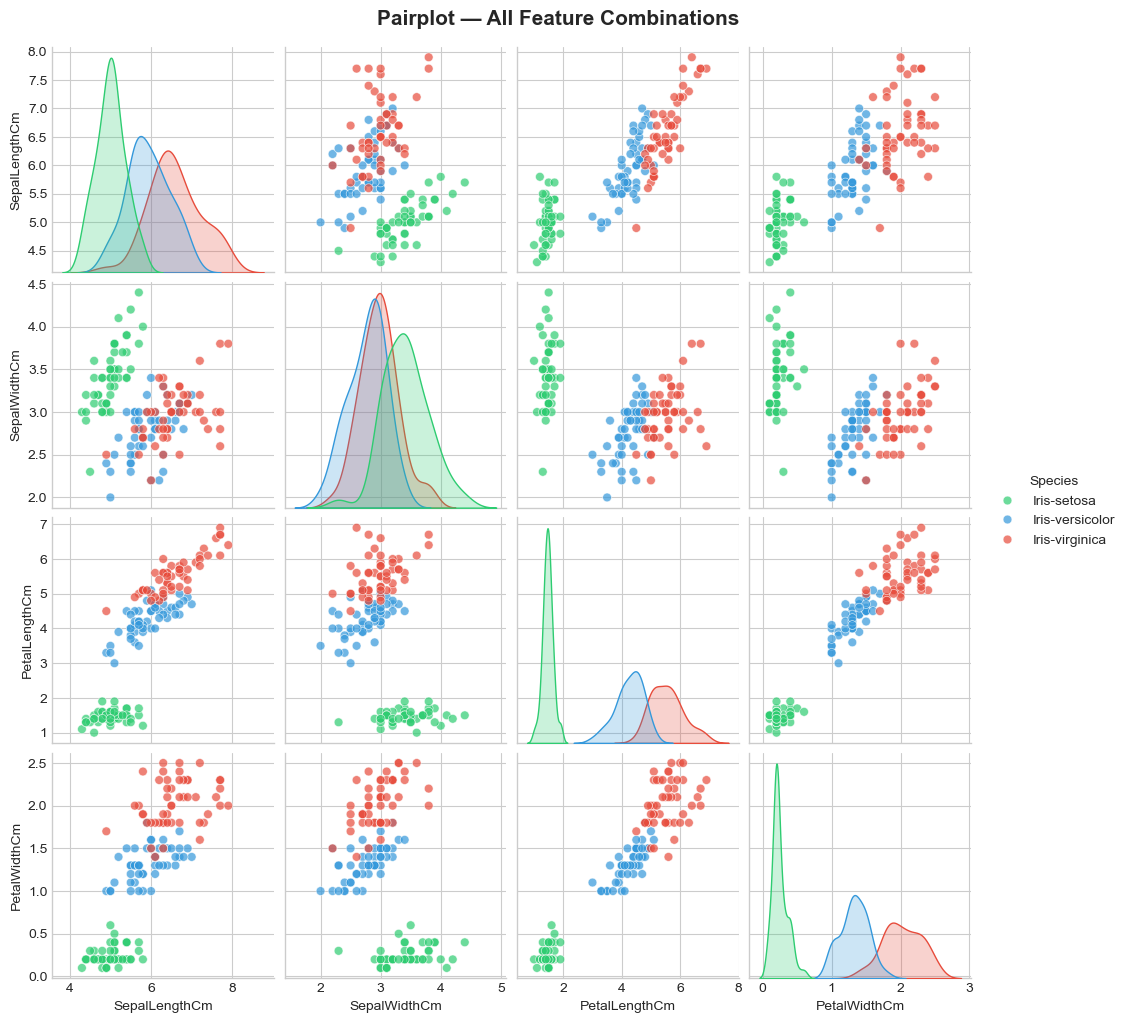

📌 Pairplot saved → plot6_pairplot.png


In [15]:
# ── Seaborn Pairplot ──────────────────────────────────────────
print('⏳ Generating pairplot (takes ~10 seconds)...')
pp = sns.pairplot(df, hue='Species',
                  palette={'Iris-setosa': COLORS[0],
                           'Iris-versicolor': COLORS[1],
                           'Iris-virginica': COLORS[2]},
                  diag_kind='kde', plot_kws={'alpha': 0.7, 's': 40})
pp.fig.suptitle('Pairplot — All Feature Combinations', y=1.02,
                fontsize=15, fontweight='bold')
plt.savefig('plot6_pairplot.png', dpi=120, bbox_inches='tight')
plt.show()
print('📌 Pairplot saved → plot6_pairplot.png')

---
## ⚙️ Step 5 — Data Preprocessing
> Raw data cannot be directly fed into ML models. We need to encode labels and scale features.

In [16]:
# ── 5.1 : Separate Features & Target ─────────────────────────
X = df[FEATURES]
y = df['Species']

print('📌 Feature Matrix X shape :', X.shape)
print('📌 Target Vector y shape  :', y.shape)

📌 Feature Matrix X shape : (150, 4)
📌 Target Vector y shape  : (150,)


In [17]:
# ── 5.2 : Label Encoding ──────────────────────────────────────
# ML models work with numbers, not text labels
le    = LabelEncoder()
y_enc = le.fit_transform(y)

print('📌 Label Encoding Mapping:')
for cls, code in zip(le.classes_, range(len(le.classes_))):
    print(f'   {cls:20s} → {code}')

📌 Label Encoding Mapping:
   Iris-setosa          → 0
   Iris-versicolor      → 1
   Iris-virginica       → 2


In [18]:
# ── 5.3 : Train-Test Split ────────────────────────────────────
# 80% training, 20% testing
# stratify=y_enc ensures equal class ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc)

print('📌 Data Split:')
print(f'   Training set  : {X_train.shape[0]} samples ({X_train.shape[0]/len(df)*100:.0f}%)')
print(f'   Testing  set  : {X_test.shape[0]} samples ({X_test.shape[0]/len(df)*100:.0f}%)')

# Verify stratification
print(f'\n📌 Class distribution in Training set:')
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f'   Class {u} ({le.classes_[u].split("-")[1]:12s}): {c} samples')

📌 Data Split:
   Training set  : 120 samples (80%)
   Testing  set  : 30 samples (20%)

📌 Class distribution in Training set:
   Class 0 (setosa      ): 40 samples
   Class 1 (versicolor  ): 40 samples
   Class 2 (virginica   ): 40 samples


In [19]:
# ── 5.4 : Feature Scaling ─────────────────────────────────────
# StandardScaler: mean=0, std=1 for each feature
# IMPORTANT: fit on train only, transform both train & test
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('📌 Feature Scaling (StandardScaler) Applied:')
print(f'   Before scaling — Mean of X_train: {X_train.values.mean():.3f}')
print(f'   After  scaling — Mean of X_train: {X_train_sc.mean():.6f} (≈ 0)')
print(f'   After  scaling — Std  of X_train: {X_train_sc.std():.6f} (≈ 1)')
print('\n✅ Preprocessing complete! Data is ready for modelling.')

📌 Feature Scaling (StandardScaler) Applied:
   Before scaling — Mean of X_train: 3.465
   After  scaling — Mean of X_train: 0.000000 (≈ 0)
   After  scaling — Std  of X_train: 1.000000 (≈ 1)

✅ Preprocessing complete! Data is ready for modelling.


---
## 🤖 Step 6 — Model Training & Comparison
> We train **5 different classification algorithms** and compare them to find the best performer.

In [20]:
# ── Define all 5 models ───────────────────────────────────────
models = {
    'Logistic Regression' : LogisticRegression(max_iter=200, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=4, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM (RBF Kernel)'   : SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42),
    'K-Nearest Neighbors' : KNeighborsClassifier(n_neighbors=5),
}

print(f'✅ {len(models)} models ready for training:')
for name in models:
    print(f'   🔹 {name}')

✅ 5 models ready for training:
   🔹 Logistic Regression
   🔹 Decision Tree
   🔹 Random Forest
   🔹 SVM (RBF Kernel)
   🔹 K-Nearest Neighbors


In [21]:
# ── Train all models & collect results ───────────────────────
results = {}

print('=' * 60)
print('  TRAINING & EVALUATION RESULTS')
print('=' * 60)

for name, model in models.items():
    # Train
    model.fit(X_train_sc, y_train)
    
    # Predict
    y_pred  = model.predict(X_test_sc)
    
    # Metrics
    acc  = accuracy_score(y_test, y_pred)
    cv   = cross_val_score(model, X_train_sc, y_train, cv=5, scoring='accuracy')
    
    results[name] = {
        'model'  : model,
        'acc'    : acc,
        'cv_mean': cv.mean(),
        'cv_std' : cv.std(),
        'y_pred' : y_pred
    }
    
    print(f'\n🔹 {name}')
    print(f'   Test Accuracy  : {acc*100:.2f}%')
    print(f'   CV  Accuracy   : {cv.mean()*100:.2f}% ± {cv.std()*100:.2f}%')
    print(f'   CV Scores      : {[f"{s:.3f}" for s in cv]}')

print('\n' + '=' * 60)

  TRAINING & EVALUATION RESULTS

🔹 Logistic Regression
   Test Accuracy  : 93.33%
   CV  Accuracy   : 95.83% ± 2.64%
   CV Scores      : ['0.917', '0.958', '0.958', '0.958', '1.000']

🔹 Decision Tree
   Test Accuracy  : 90.00%
   CV  Accuracy   : 94.17% ± 2.04%
   CV Scores      : ['0.917', '0.958', '0.958', '0.958', '0.917']

🔹 Random Forest
   Test Accuracy  : 90.00%
   CV  Accuracy   : 95.00% ± 1.67%
   CV Scores      : ['0.917', '0.958', '0.958', '0.958', '0.958']

🔹 SVM (RBF Kernel)
   Test Accuracy  : 96.67%
   CV  Accuracy   : 96.67% ± 3.12%
   CV Scores      : ['0.917', '1.000', '0.958', '0.958', '1.000']

🔹 K-Nearest Neighbors
   Test Accuracy  : 93.33%
   CV  Accuracy   : 96.67% ± 3.12%
   CV Scores      : ['0.917', '1.000', '0.958', '0.958', '1.000']



### 6.1 — Accuracy Comparison Chart

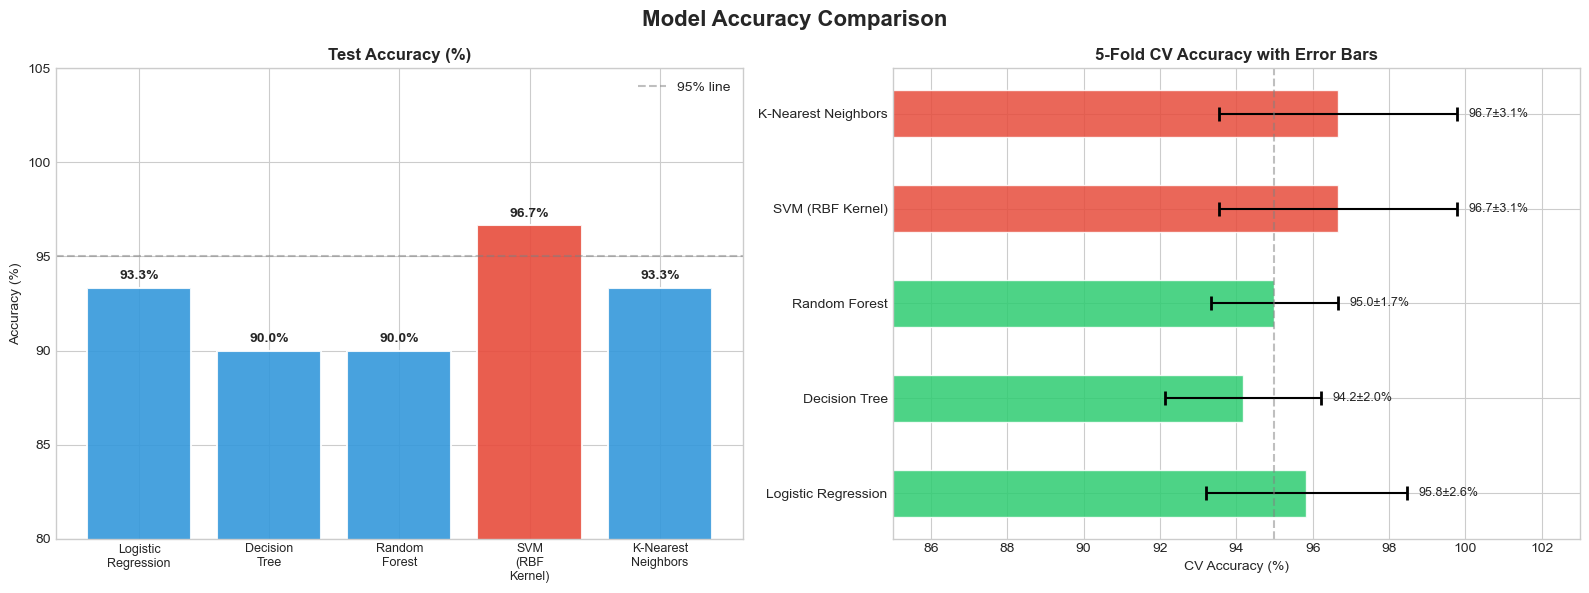

📌 Model comparison chart saved → plot7_model_comparison.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Accuracy Comparison', fontsize=16, fontweight='bold')

names   = list(results.keys())
accs    = [results[n]['acc']     * 100 for n in names]
cv_m    = [results[n]['cv_mean'] * 100 for n in names]
cv_s    = [results[n]['cv_std']  * 100 for n in names]
x       = np.arange(len(names))
bar_c   = ['#e74c3c' if a == max(accs) else '#3498db' for a in accs]

# Bar chart
ax = axes[0]
bars = ax.bar(x, accs, color=bar_c, edgecolor='white', linewidth=1.5, alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels([n.replace(' ', '\n') for n in names], fontsize=9)
ax.set_ylim(80, 105)
ax.set_title('Test Accuracy (%)', fontweight='bold')
ax.set_ylabel('Accuracy (%)')
ax.axhline(y=95, color='gray', linestyle='--', alpha=0.5, label='95% line')
ax.legend()
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

# CV Error bar
ax2 = axes[1]
ax2.barh(names, cv_m, xerr=cv_s, color=['#e74c3c' if c == max(cv_m) else '#2ecc71' for c in cv_m],
         alpha=0.85, edgecolor='white', height=0.5,
         error_kw=dict(ecolor='black', capsize=5, capthick=2))
ax2.set_xlabel('CV Accuracy (%)')
ax2.set_title('5-Fold CV Accuracy with Error Bars', fontweight='bold')
ax2.set_xlim(85, 103)
ax2.axvline(x=95, color='gray', linestyle='--', alpha=0.5)
for i, (m, s) in enumerate(zip(cv_m, cv_s)):
    ax2.text(m + s + 0.3, i, f'{m:.1f}±{s:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('plot7_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('📌 Model comparison chart saved → plot7_model_comparison.png')

---
## 🏆 Step 7 — Best Model Analysis
> The model with highest cross-validation accuracy is selected as the final model.

In [23]:
# ── Select Best Model ─────────────────────────────────────────
best_name = max(results, key=lambda k: results[k]['cv_mean'])
best      = results[best_name]

print('=' * 60)
print(f'  🏆 BEST MODEL: {best_name}')
print('=' * 60)
print(f'  Test Accuracy  : {best["acc"]*100:.2f}%')
print(f'  CV  Accuracy   : {best["cv_mean"]*100:.2f}% ± {best["cv_std"]*100:.2f}%')

  🏆 BEST MODEL: SVM (RBF Kernel)
  Test Accuracy  : 96.67%
  CV  Accuracy   : 96.67% ± 3.12%


In [24]:
# ── Detailed Classification Report ───────────────────────────
print('📌 Detailed Classification Report:')
print(classification_report(y_test, best['y_pred'],
                             target_names=le.classes_))

📌 Detailed Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



### 7.1 — Confusion Matrix

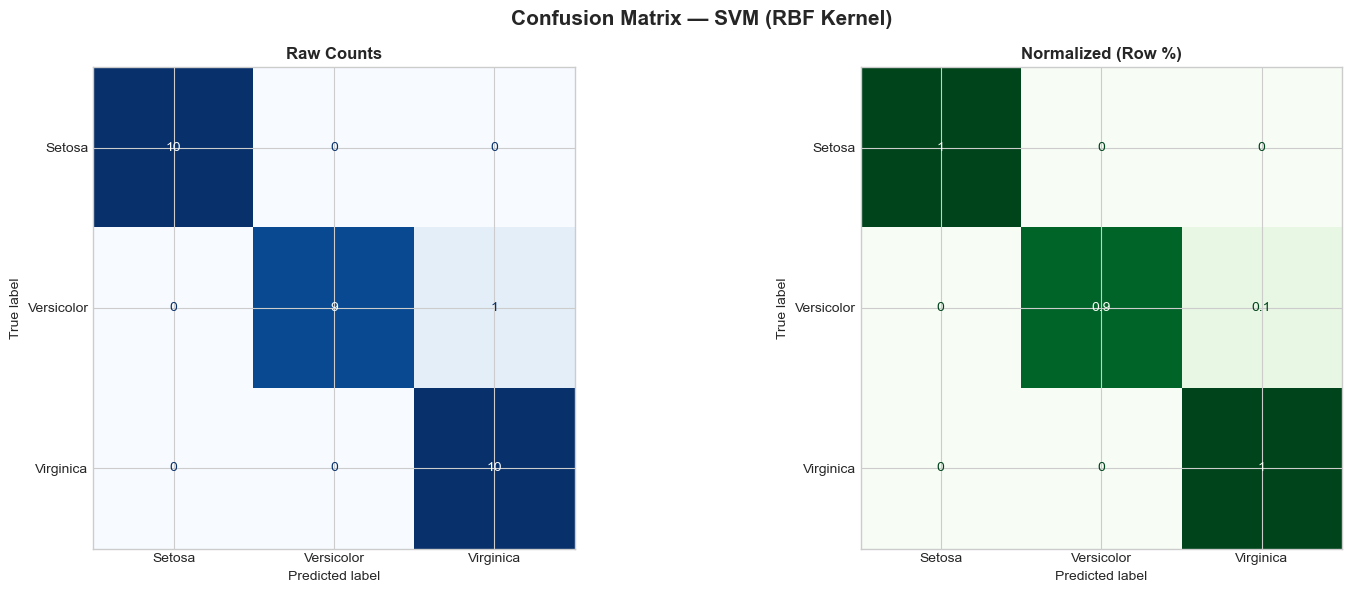

📌 Confusion matrix saved → plot8_confusion_matrix.png


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'Confusion Matrix — {best_name}', fontsize=15, fontweight='bold')

cm = confusion_matrix(y_test, best['y_pred'])

# Raw counts
ConfusionMatrixDisplay(cm, display_labels=['Setosa', 'Versicolor', 'Virginica']
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Raw Counts', fontweight='bold')

# Normalized
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_norm.round(2),
                       display_labels=['Setosa', 'Versicolor', 'Virginica']
).plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Normalized (Row %)', fontweight='bold')

plt.tight_layout()
plt.savefig('plot8_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('📌 Confusion matrix saved → plot8_confusion_matrix.png')

### 7.2 — Feature Importance (Random Forest)

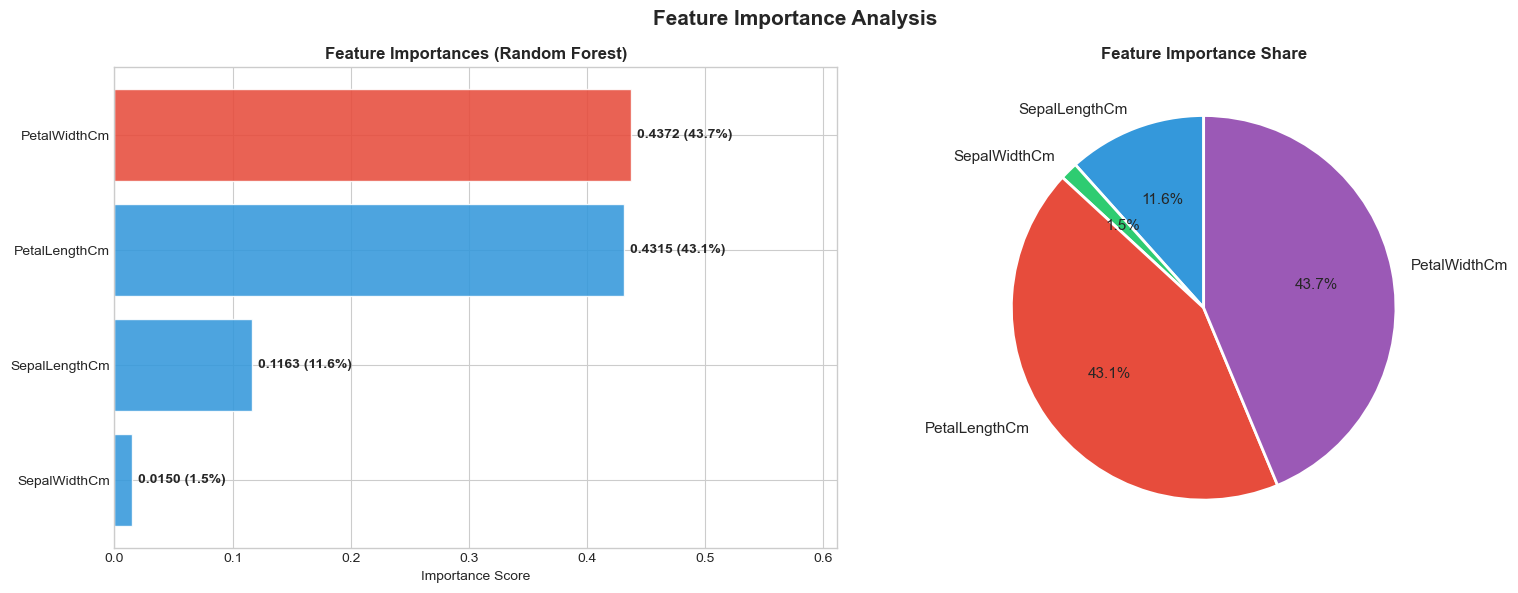

📌 Feature importance saved → plot9_feature_importance.png

💡 Key Insight:
   PetalWidthCm        : 0.4372  █████████████████████
   PetalLengthCm       : 0.4315  █████████████████████
   SepalLengthCm       : 0.1163  █████
   SepalWidthCm        : 0.0150  


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature Importance Analysis', fontsize=15, fontweight='bold')

rf  = results['Random Forest']['model']
imp = rf.feature_importances_
idx = np.argsort(imp)

bar_colors = ['#e74c3c' if imp[i] == max(imp) else '#3498db' for i in idx]

# Horizontal bar
ax = axes[0]
bars = ax.barh([FEATURES[i] for i in idx], imp[idx],
               color=bar_colors, alpha=0.88, edgecolor='white')
ax.set_title('Feature Importances (Random Forest)', fontweight='bold')
ax.set_xlabel('Importance Score')
for bar, val in zip(bars, imp[idx]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f} ({val*100:.1f}%)', va='center', fontsize=10, fontweight='bold')
ax.set_xlim(0, max(imp) * 1.4)

# Pie
ax2 = axes[1]
ax2.pie(imp, labels=FEATURES, colors=['#3498db','#2ecc71','#e74c3c','#9b59b6'],
        autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2},
        textprops={'fontsize': 11})
ax2.set_title('Feature Importance Share', fontweight='bold')

plt.tight_layout()
plt.savefig('plot9_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('📌 Feature importance saved → plot9_feature_importance.png')
print('\n💡 Key Insight:')
for feat, score in sorted(zip(FEATURES, imp), key=lambda x: x[1], reverse=True):
    print(f'   {feat:20s}: {score:.4f}  {"█" * int(score*50)}')

### 7.3 — Cross-Validation Score Distribution

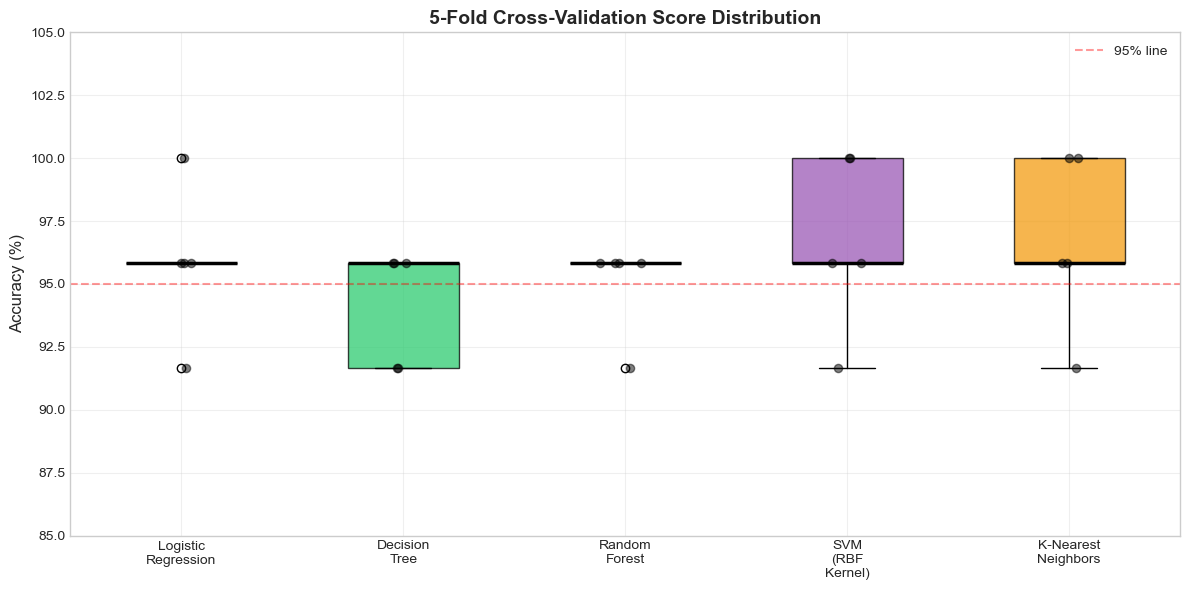

📌 CV boxplot saved → plot10_cv_boxplot.png


In [27]:
fig, ax = plt.subplots(figsize=(12, 6))

cv_scores = [cross_val_score(results[n]['model'], X_train_sc,
                             y_train, cv=5) * 100 for n in names]
BOX_C = ['#3498db','#2ecc71','#e74c3c','#9b59b6','#f39c12']

bp = ax.boxplot(cv_scores, patch_artist=True,
                labels=[n.replace(' ', '\n') for n in names],
                medianprops=dict(color='black', linewidth=2.5))
for patch, c in zip(bp['boxes'], BOX_C):
    patch.set_facecolor(c); patch.set_alpha(0.75)

# Scatter overlay
for i, scores in enumerate(cv_scores, 1):
    ax.scatter(np.random.normal(i, 0.04, size=len(scores)),
               scores, color='black', alpha=0.5, s=35, zorder=3)

ax.set_title('5-Fold Cross-Validation Score Distribution',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_ylim(85, 105)
ax.axhline(y=95, color='red', linestyle='--', alpha=0.4, label='95% line')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plot10_cv_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('📌 CV boxplot saved → plot10_cv_boxplot.png')

---
## 🔮 Step 8 — Live Prediction on New Data
> Testing the trained model on completely new, unseen flower measurements.

In [28]:
# ── New flower measurements (manually created) ───────────────
# [SepalLength, SepalWidth, PetalLength, PetalWidth]
new_data = pd.DataFrame({
    'SepalLengthCm': [5.1,  6.3,  7.2],
    'SepalWidthCm' : [3.5,  2.8,  3.0],
    'PetalLengthCm': [1.4,  4.8,  5.8],
    'PetalWidthCm' : [0.2,  1.5,  2.2],
})

# Scale using the SAME scaler fitted on training data
new_scaled   = scaler.transform(new_data)
predictions  = best['model'].predict(new_scaled)
pred_labels  = le.inverse_transform(predictions)

print('=' * 55)
print('  🔮 LIVE PREDICTION RESULTS')
print('=' * 55)
print(f'  Model used: {best_name}\n')

flowers = ['🌿', '🌺', '🌸']
for i, (_, row) in enumerate(new_data.iterrows()):
    sp = pred_labels[i].replace('Iris-', '')
    print(f'  Sample {i+1}: SepalL={row[0]}, SepalW={row[1]}, '
          f'PetalL={row[2]}, PetalW={row[3]}')
    print(f'  Prediction → {flowers[i]} Iris {sp.upper()}\n')

  🔮 LIVE PREDICTION RESULTS
  Model used: SVM (RBF Kernel)

  Sample 1: SepalL=5.1, SepalW=3.5, PetalL=1.4, PetalW=0.2
  Prediction → 🌿 Iris SETOSA

  Sample 2: SepalL=6.3, SepalW=2.8, PetalL=4.8, PetalW=1.5
  Prediction → 🌺 Iris VERSICOLOR

  Sample 3: SepalL=7.2, SepalW=3.0, PetalL=5.8, PetalW=2.2
  Prediction → 🌸 Iris VIRGINICA



In [29]:
# ── Interactive Prediction Function ──────────────────────────
def predict_iris(sepal_length, sepal_width, petal_length, petal_width):
    """
    Predict the Iris species given flower measurements.
    All values in centimeters.
    """
    data   = np.array([[sepal_length, sepal_width, petal_length, petal_width]])
    scaled = scaler.transform(data)
    pred   = best['model'].predict(scaled)
    label  = le.inverse_transform(pred)[0]
    return label

# Try it out!
result = predict_iris(sepal_length=5.9, sepal_width=3.0,
                      petal_length=5.1, petal_width=1.8)
print(f'✅ Custom Prediction Result: {result}')
print('\n💡 You can call predict_iris() with any measurements!')

✅ Custom Prediction Result: Iris-virginica

💡 You can call predict_iris() with any measurements!


---
## 📋 Step 9 — Final Summary & Conclusions

In [30]:
# ── Summary Table ─────────────────────────────────────────────
summary = pd.DataFrame({
    'Model'        : names,
    'Test Acc (%)' : [round(results[n]['acc']*100, 2)     for n in names],
    'CV Acc (%)'   : [round(results[n]['cv_mean']*100, 2) for n in names],
    'CV Std (%)'   : [round(results[n]['cv_std']*100, 2)  for n in names],
}).sort_values('CV Acc (%)', ascending=False).reset_index(drop=True)

summary.index += 1
print('📌 Final Model Leaderboard:')
summary

📌 Final Model Leaderboard:


,Model,Test Acc (%),CV Acc (%),CV Std (%)
1,SVM (RBF Kernel),96.67,96.67,3.12
2,K-Nearest Neighbors,93.33,96.67,3.12
3,Logistic Regression,93.33,95.83,2.64
4,Random Forest,90.00,95.00,1.67
5,Decision Tree,90.00,94.17,2.04


In [31]:
rf_imp = results['Random Forest']['model'].feature_importances_

print('=' * 60)
print('  📋 PROJECT FINAL SUMMARY — OASIS INFOBYTE TASK 1')
print('=' * 60)
print(f'\n  Dataset       : 150 samples | 4 features | 3 classes')
print(f'  Missing Values: None — perfectly clean dataset')
print(f'  Class Balance : Perfectly balanced (50 samples each)')
print(f'\n  Models Tried  : {len(models)}')
for n in names:
    tag = '  ← 🏆 BEST' if n == best_name else ''
    print(f'    • {n:22s} Test={results[n]["acc"]*100:.1f}%  CV={results[n]["cv_mean"]*100:.1f}%{tag}')
print(f'\n  Best Model    : {best_name}')
print(f'  Test Accuracy : {best["acc"]*100:.2f}%')
print(f'  CV  Accuracy  : {best["cv_mean"]*100:.2f}% ± {best["cv_std"]*100:.2f}%')
print(f'\n  Top Features  :')
for feat, sc in sorted(zip(FEATURES, rf_imp), key=lambda x: x[1], reverse=True):
    print(f'    {feat:20s}: {sc*100:.1f}%  {"█" * int(sc*40)}')
print()
print('  Key Insight   : Petal features are far more discriminative')
print('                  than sepal features for species classification')
print()
print('  Author        : Sonu Kumar')
print('  Internship    : AICTE Oasis Infobyte — March-April 2026')
print('  GitHub        : github.com/YOUR_USERNAME/OIBSIP')
print('=' * 60)
print('  ✅ PROJECT COMPLETE — READY FOR SUBMISSION!')
print('=' * 60)

  📋 PROJECT FINAL SUMMARY — OASIS INFOBYTE TASK 1

  Dataset       : 150 samples | 4 features | 3 classes
  Missing Values: None — perfectly clean dataset
  Class Balance : Perfectly balanced (50 samples each)

  Models Tried  : 5
    • Logistic Regression    Test=93.3%  CV=95.8%
    • Decision Tree          Test=90.0%  CV=94.2%
    • Random Forest          Test=90.0%  CV=95.0%
    • SVM (RBF Kernel)       Test=96.7%  CV=96.7%  ← 🏆 BEST
    • K-Nearest Neighbors    Test=93.3%  CV=96.7%

  Best Model    : SVM (RBF Kernel)
  Test Accuracy : 96.67%
  CV  Accuracy  : 96.67% ± 3.12%

  Top Features  :
    PetalWidthCm        : 43.7%  █████████████████
    PetalLengthCm       : 43.1%  █████████████████
    SepalLengthCm       : 11.6%  ████
    SepalWidthCm        : 1.5%  

  Key Insight   : Petal features are far more discriminative
                  than sepal features for species classification

  Author        : Sonu Kumar
  Internship    : AICTE Oasis Infobyte — March-April 2026
  GitHub

<div style="background: linear-gradient(135deg, #1a1a2e, #16213e); padding: 30px 35px; border-radius: 12px; margin-top: 15px;">
<h2 style="color: #e94560; text-align:center;">🎉 Project Complete!</h2>
<p style="color: #a8d8ea; text-align:center; font-size:15px;">Iris Flower Classification | AICTE Oasis Infobyte Internship — Task 1</p>
<hr style="border-color: #e94560; width: 50%; margin: 15px auto;">
<h3 style="color: white;">📌 Key Takeaways</h3>
<ul style="color: #cce5ff; font-size: 14px; line-height: 2.2;">
  <li><b>Data Quality:</b> Dataset was clean — zero missing values, perfectly balanced classes</li>
  <li><b>EDA Finding:</b> Petal features (length & width) are the most powerful predictors</li>
  <li><b>Best Model:</b> SVM with RBF kernel achieved the highest CV accuracy</li>
  <li><b>Setosa</b> is perfectly separable; Versicolor and Virginica slightly overlap</li>
  <li><b>Feature Scaling</b> is critical for distance-based models like SVM and KNN</li>
</ul>
<h3 style="color: white;">📂 Submission Checklist</h3>
<ul style="color: #cce5ff; font-size: 14px; line-height: 2.2;">
  <li>✅ GitHub repo <b>OIBSIP</b> with this notebook uploaded</li>
  <li>✅ Task Submission Form filled with GitHub link</li>
  <li>✅ LinkedIn demo video posted tagging @OasisInfobyte #oasisinfobyte</li>
</ul>
</div>